In [1]:
import numpy as np
import os
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
#from keras.preprocessing.image import ImageDataGenerator
from keras.preprocessing import image

In [2]:
plt.style.use("ggplot")
%matplotlib inline

In [3]:
main_train_dir = os.path.join(r"C:\Users\bhavy\PycharmProjects\CRUIP\.venv\CurrencyPrediction\ModelGeneration\ModelDataset/Train/")
main_test_dir = os.path.join(r"C:\Users\bhavy\PycharmProjects\CRUIP\.venv\CurrencyPrediction\ModelGeneration\ModelDataset/Test/")

print(main_train_dir)
print(main_test_dir)

C:\Users\bhavy\PycharmProjects\CRUIP\.venv\CurrencyPrediction\ModelGeneration\ModelDataset/Train/
C:\Users\bhavy\PycharmProjects\CRUIP\.venv\CurrencyPrediction\ModelGeneration\ModelDataset/Test/


In [4]:
two_thousand_dir = os.path.join(r"C:\Users\bhavy\PycharmProjects\CRUIP\.venv\CurrencyPrediction\ModelGeneration\ModelDataset/Train/2Thousandnote/")
two_thousand_dir = os.path.join(r"C:\Users\bhavy\PycharmProjects\CRUIP\.venv\CurrencyPrediction\ModelGeneration\ModelDataset/Train/2Thousandnote/")
five_hundered_dir = os.path.join(r"C:\Users\bhavy\PycharmProjects\CRUIP\.venv\CurrencyPrediction\ModelGeneration\ModelDataset/Train/5Hundrednote/")
two_hundered_dir = os.path.join(r"C:\Users\bhavy\PycharmProjects\CRUIP\.venv\CurrencyPrediction\ModelGeneration\ModelDataset/Train/2Hundrednote/")
one_hundered_dir = os.path.join(r"C:\Users\bhavy\PycharmProjects\CRUIP\.venv\CurrencyPrediction\ModelGeneration\ModelDataset/Train/1Hundrednote/")
fifty_dir = os.path.join(r"C:\Users\bhavy\PycharmProjects\CRUIP\.venv\CurrencyPrediction\ModelGeneration\ModelDataset/Train/Fiftynote/")
twenty_dir = os.path.join(r"C:\Users\bhavy\PycharmProjects\CRUIP\.venv\CurrencyPrediction\ModelGeneration\ModelDataset/Train/Twentynote/")
ten_dir = os.path.join(r"C:\Users\bhavy\PycharmProjects\CRUIP\.venv\CurrencyPrediction\ModelGeneration\ModelDataset/Train/Tennote/")

In [5]:
two_thousand_names = os.listdir(two_thousand_dir)
five_hundered_names = os.listdir(five_hundered_dir)
two_hundered_names = os.listdir(two_hundered_dir)
one_hundered_names = os.listdir(one_hundered_dir)
fifty_names = os.listdir(fifty_dir)
twenty_names = os.listdir(twenty_dir)
ten_names = os.listdir(ten_dir)


print(two_thousand_names[:10])
print(five_hundered_names[:10])
print(two_hundered_names[:10])
print(one_hundered_names[:10])
print(fifty_names[:10])
print(twenty_names[:10])
print(ten_names[:10])

['1.jpg', '10.jpg', '11.jpg', '12.jpg', '13.jpg', '16.jpg', '17.jpg', '19.jpg', '2.jpg', '20.jpg']
['12.jpg', '13.jpg', '15.jpg', '16.jpg', '18.jpg', '19.jpg', '2.jpg', '20.jpg', '21.jpg', '22.jpg']
['1.jpg', '10.jpg', '11.jpg', '12.jpg', '13.jpg', '17.jpg', '18.jpg', '19.jpg', '2.jpg', '20.jpg']
['1.jpg', '10.jpg', '11.jpg', '13.jpg', '18.jpg', '2.jpg', '20.jpg', '21.jpg', '22.jpg', '23.jpg']
['1.jpg', '11.jpg', '12.jpg', '13.jpg', '14.jpg', '15.jpg', '16.jpg', '17.jpg', '18.jpg', '19.jpg']
['1.jpg', '10.jpg', '11.jpg', '12.jpg', '13.jpg', '15.jpg', '16.jpg', '17.jpg', '2.jpg', '20.jpg']
['1.jpg', '10.jpg', '12.jpg', '13.jpg', '14.jpg', '15.jpg', '16.jpg', '17.jpg', '18.jpg', '19.jpg']


In [6]:
print(f"total training of 2Thousand Notes : {len(two_thousand_names)}")
print(f"total training of 5Hundered Notes : {len(five_hundered_names)}")
print(f"total training of 2Hundered Notes : {len(two_hundered_names)}")
print(f"total training of 1Hundered Notes: {len(one_hundered_names)}")
print(f"total training of 50Notes : {len(fifty_names)}")
print(f"total training of 20Notes : {len(twenty_names)}")
print(f"total training of 10Notes : {len(ten_names)}")

total training of 2Thousand Notes : 21
total training of 5Hundered Notes : 22
total training of 2Hundered Notes : 22
total training of 1Hundered Notes: 22
total training of 50Notes : 22
total training of 20Notes : 22
total training of 10Notes : 22


In [7]:
# parameters for graph we'll output images in a 4x4
nrows = 4
ncols = 4

# Index for iterating over images
pic_index = 0

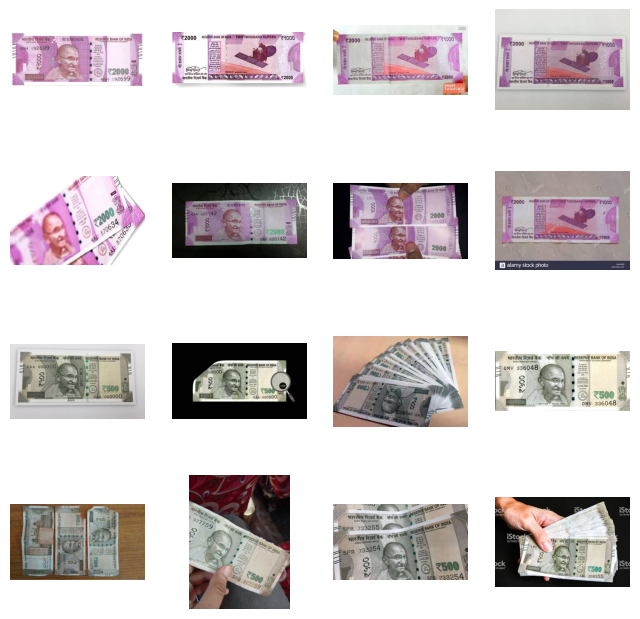

In [8]:
# set up matplotlib fig, and size it to fit 4x4 pics
fig = plt.gcf()
fig.set_size_inches(ncols * 2, nrows * 2)

pic_index += 8

two_thousand_pix = [os.path.join(two_thousand_dir, fname) 
                for fname in two_thousand_names[pic_index-8:pic_index]]

five_hundered_pix = [os.path.join(five_hundered_dir, fname) 
                for fname in five_hundered_names[pic_index-8:pic_index]]


for i, img in enumerate(two_thousand_pix + five_hundered_pix):
    sub_plot = plt.subplot(nrows, ncols, i + 1)
    sub_plot.axis("Off")
    img_read = mpimg.imread(img)
    plt.imshow(img_read)
    
plt.show()

In [9]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation="relu", input_shape=(150,150,3)),
    tf.keras.layers.MaxPooling2D(2,2),
    
    tf.keras.layers.Conv2D(32, (3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Dropout(0.2),
    
    tf.keras.layers.Conv2D(64, (3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D(2,2),
    
    tf.keras.layers.Conv2D(64, (3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D(2,2),
    
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(7, activation="softmax")
])

C:\Users\bhavy\PycharmProjects\CRUIP\.venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:99: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(


In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 72, 72, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 36, 36, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 36, 36, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 34, 34, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 17, 17, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 15, 15, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 3136)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         401,536 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 7)                   │             903 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 468,007 (1.79 MB)

 Trainable params: 468,007 (1.79 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

In [12]:
train_datagen = ImageDataGenerator(rescale=1/255)
validation_datagen = ImageDataGenerator(rescale=1/255)

# Flow training images in batches of 128 using train_datagen generator
train_generator = train_datagen.flow_from_directory(main_train_dir,
                                                   batch_size=64,
                                                   target_size=(150,150),
                                                   class_mode="categorical")

validation_generator = validation_datagen.flow_from_directory(main_test_dir,
                                                             batch_size=16,
                                                              target_size=(150,150),
                                                             class_mode="categorical")

Found 153 images belonging to 7 classes.
Found 43 images belonging to 7 classes.


In [13]:
history = model.fit(train_generator,   
                    epochs=100,
                    steps_per_epoch=len(train_generator),
                    verbose=1,
                    validation_data=validation_generator,
                    validation_steps=len(validation_generator))

Epoch 1/100


C:\Users\bhavy\PycharmProjects\CRUIP\.venv\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:120: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 680ms/step - accuracy: 0.1285 - loss: 1.9842 - val_accuracy: 0.2558 - val_loss: 1.9419
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 3/100


C:\Users\bhavy\AppData\Local\Programs\Python\Python310\lib\contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 321ms/step - accuracy: 0.1904 - loss: 1.9378 - val_accuracy: 0.2093 - val_loss: 1.9402
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 405ms/step - accuracy: 0.1417 - loss: 1.9375 - val_accuracy: 0.2093 - val_loss: 1.9310
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 410ms/step - accuracy: 0.2524 - loss: 1.9194 - val_accuracy: 0.2093 - val_loss: 1.9051
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 314ms/step - accuracy: 0.1848 - loss: 1.8977 - val_accuracy: 0.2558 - val_loss: 1.8329
Epoch 10/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0000e+00 - loss: 

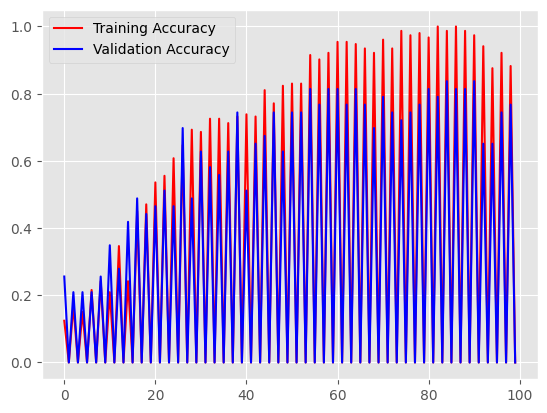

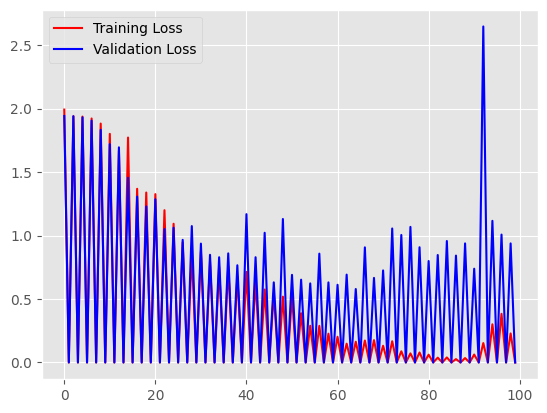

In [14]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]

loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs = range(len(acc))

plt.plot(epochs, acc, "r", label="Training Accuracy")
plt.plot(epochs, val_acc, "b", label="Validation Accuracy")

plt.legend()
plt.figure()

plt.plot(epochs, loss, "r", label="Training Loss")
plt.plot(epochs, val_loss, "b", label="Validation Loss")

plt.legend()
plt.show()

In [15]:
'''
path = r"C:\Users\bhavy\PycharmProjects\CRUIP\.venv\CurrencyPrediction\ModelGeneration\ModelDataset\Test\1Hundrednote/1.jpg"
img = image.load_img(path, target_size=(150, 150))
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)

images = np.vstack([x])
predict_x=model.predict(images) 
classes = np.argmax(predict_x,axis=1)



if classes[0] == 1:
    print(path + " is Two Thousand Rupees")
elif classes[0] == 2:
    print(path + " is Five Hundered Rupees")
elif classes[0] == 3:
    print(path + " is Two Hundered Rupees")
elif classes[0] == 4:
    print(path + " is One Hundered Rupees")
elif classes[0] == 5:
    print(path + " is Fifty Rupees")
elif classes[0] == 6:
    print(path + " is Twenty Rupees")
else:
    print(path + " is Ten Rupees")
    
img = mpimg.imread(path)
plt.imshow(img)
plt.show()
'''

SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 12-13: truncated \UXXXXXXXX escape (226146022.py, line 31)